In [2]:
import DataLoaderPipeline as dplmodule
from DataLoaderPipeline import DataLoaderPipeline
import importlib
importlib.reload(dplmodule)
DATA_PATH = "data/CASIA_FASD_V3_224x224/DATA"
DATA_MAP_PATH = "data_maps/CASIA_FASD_V3_30percent_uniformSampling.json"

all_subjects = [f"{i:02d}" for i in range(1, 51)]  # Generate subject IDs from '01' to '50'.
train_subs = all_subjects[:20]
val_subs = all_subjects[20:25] 
test_subs = all_subjects[20:] 
config={
        "data_params": {
            "dataset_path": "data/CASIA_FASD_v3_224x224/DATA",
            "input_size": [224,224,3],
            "pixel_range": [0.0,1.0],
            "batch_size": 32                
        },
        
        "filtering_params": {
            "data_map_path": "data_maps/CASIA_FASD_v3_all.json",
        },
        
        "augmentation_params": {
            "rotation_range": 0.15,
            "horizontal_flip": 0,
            "brightness_range": [0.8,1.2],
            "zoom_range": 0.1
        },
      
    }

dlp = DataLoaderPipeline(data_params=config["data_params"],
                         filtering_params=config["filtering_params"],
                         augmentation_params=config["augmentation_params"])


train_ds = dlp.build_pipeline(train_subs, balanced=True, augment=True)
val_ds   = dlp.build_pipeline(val_subs, balanced=False, augment=False)
test_ds  = dlp.build_pipeline(test_subs, balanced=False, augment=False)
for ds in [train_ds, val_ds, test_ds]:
    dlp.audit_dataset(ds, batchs=20)

Successfully loaded 50 subjects from JSON.
Auditing up to 20 batches...

POST-CREATION DATASET AUDIT
Total Samples Audited: 640
Real Samples:  313 (48.9%)
Spoof Samples: 327 (51.1%)
------------------------------
Pixel Range: [0.00 to 1.00]
Status: Normalization OK
Status: Balance OK (~50/50)

Auditing up to 20 batches...

POST-CREATION DATASET AUDIT
Total Samples Audited: 640
Real Samples:  640 (100.0%)
Spoof Samples: 0 (0.0%)
------------------------------
Pixel Range: [0.00 to 1.00]
Status: Normalization OK

Auditing up to 20 batches...

POST-CREATION DATASET AUDIT
Total Samples Audited: 640
Real Samples:  640 (100.0%)
Spoof Samples: 0 (0.0%)
------------------------------
Pixel Range: [0.00 to 1.00]
Status: Normalization OK



In [59]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_multi_colorspace_model(input_shape=(224, 224, 3)):
    # 1. Input Layer (RGB)
    input_rgb = layers.Input(shape=input_shape, name="input_rgb")
    
    # 2. Color Space Transformations
    # Note: TF expects images in [0, 1] for these built-in functions
    input_hsv = layers.Lambda(lambda x: tf.image.rgb_to_hsv(x), name="rgb_to_hsv")(input_rgb)
    input_ycbcr = layers.Lambda(lambda x: tf.image.rgb_to_yuv(x), name="rgb_to_ycbcr")(input_rgb)
    
    # 3. Concatenate all 9 channels (3 RGB + 3 HSV + 3 YCbCr)
    # Shape transition: (Batch, 224, 224, 3) -> (Batch, 224, 224, 9)
    merged_channels = layers.Concatenate(axis=-1, name="nine_channel_fusion")(
        [input_rgb, input_hsv, input_ycbcr]
    )
    
    # 4. Feature Extraction (Example: Lightweight CNN for Spoofing)
    # Since you have 9 channels, the first Conv layer will learn cross-color correlations
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(merged_channels)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    
    # 5. Output Layer (Binary Classification: Real vs Spoof)
    output = layers.Dense(1, activation='sigmoid', name="classifier")(x)
    
    model = models.Model(inputs=input_rgb, outputs=output, name="MultiColorspace_Spoofing_Detector")
    return model

# Instantiate for your TrainingPipeline
model = build_multi_colorspace_model()
model.summary()

Model: "MultiColorspace_Spoofing_Detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_rgb           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_to_hsv (Lambda) │ (None, 224, 224,  │          0 │ input_rgb[0][0]   │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_to_ycbcr        │ (None, 224, 224,  │          0 │ input_rgb[0][0]   │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nine_channel_fusion │ (None, 224, 224,  │          0 │ input_rgb[0][0],  │
│ (Concatenate)       │ 9)                │            │ rgb_to_hsv[0][0], │
│                     │                   │            │ rgb_to_ycbcr[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 224, 224,  │      2,624 │ nine_channel_fus… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 56, 56,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling2d_3[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,697 (116.00 KB)

 Trainable params: 29,633 (115.75 KB)

 Non-trainable params: 64 (256.00 B)

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the layers you want to visualize
layer_outputs = [
    model.get_layer("nine_channel_fusion").output,
    model.get_layer("conv2d_1").output
]

# 2. Create a model that returns these outputs
visualization_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)

# 3. Get a sample from your validation dataset (CASIA-FASD)
# Assuming val_ds is a batched tf.data.Dataset
sample_batch, _ = next(iter(val_ds))
single_img = sample_batch[2:3] # Shape: (1, 224, 224, 3)

# 4. Predict to get the feature maps
fusion_output, conv_output = visualization_model.predict(single_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


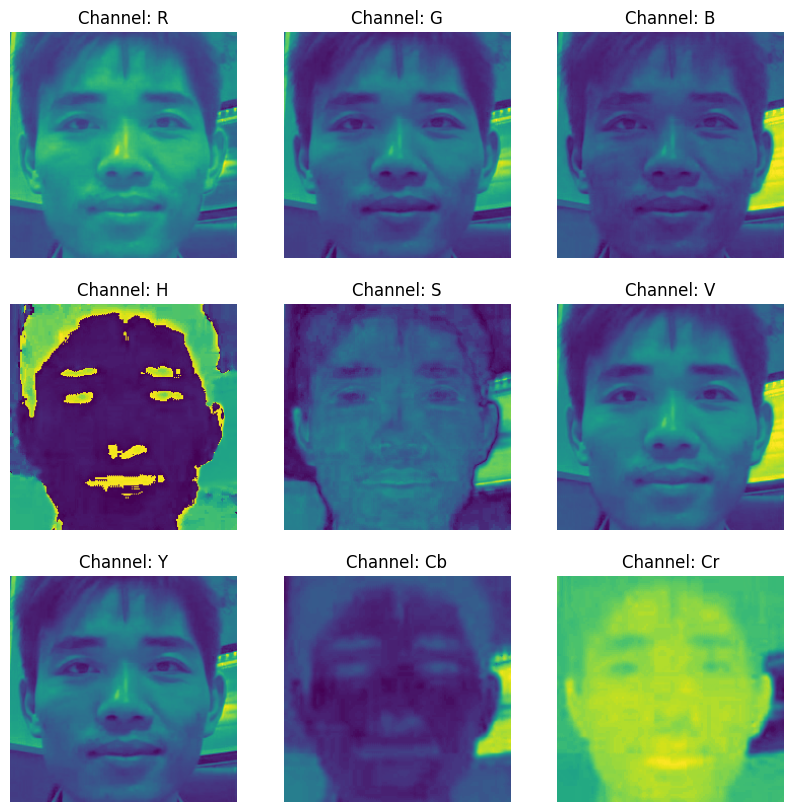

In [57]:
def plot_nine_channels(fusion_data):
    channel_names = ['R', 'G', 'B', 'H', 'S', 'V', 'Y', 'Cb', 'Cr']
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(fusion_data[0, :, :, i], cmap='viridis')
        plt.title(f"Channel: {channel_names[i]}")
        plt.axis('off')
    plt.show()

plot_nine_channels(fusion_output)

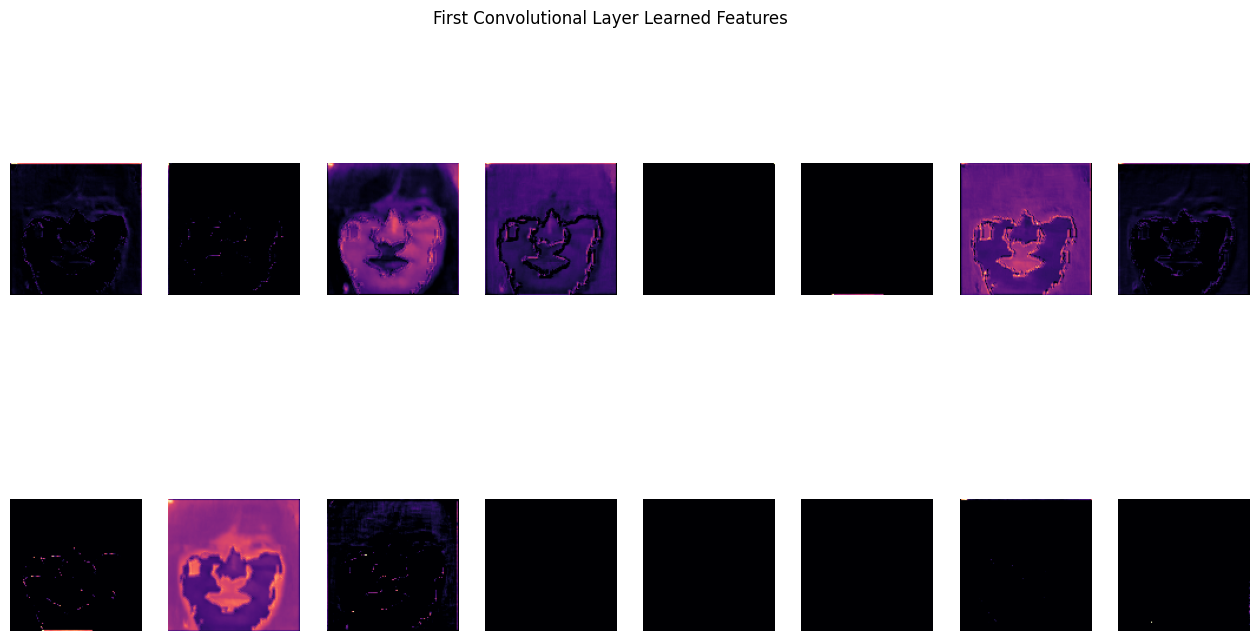

In [7]:
def plot_conv_layers(conv_data, num_filters=16):
    plt.figure(figsize=(16, 8))
    for i in range(num_filters):
        plt.subplot(2, 8, i + 1)
        plt.imshow(conv_data[0, :, :, i], cmap='magma')
        plt.axis('off')
    plt.suptitle("First Convolutional Layer Learned Features")
    plt.show()

plot_conv_layers(conv_output)

TensorShape([224, 224, 3])

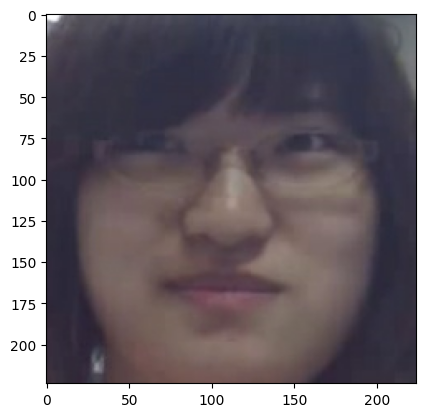

In [ ]:
plt.imshow(single_img[0])


In [20]:
# 1. Input Layer (RGB)
input_rgb = layers.Input(shape=(244, 244, 3), name="input_rgb")

# 2. Color Space Transformations
# Note: TF expects images in [0, 1] for these built-in functions
input_hsv = layers.Lambda(lambda x: tf.image.rgb_to_hsv(x), name="rgb_to_hsv")(input_rgb)
input_ycbcr = layers.Lambda(lambda x: tf.image.rgb_to_yuv(x), name="rgb_to_ycbcr")(input_rgb)

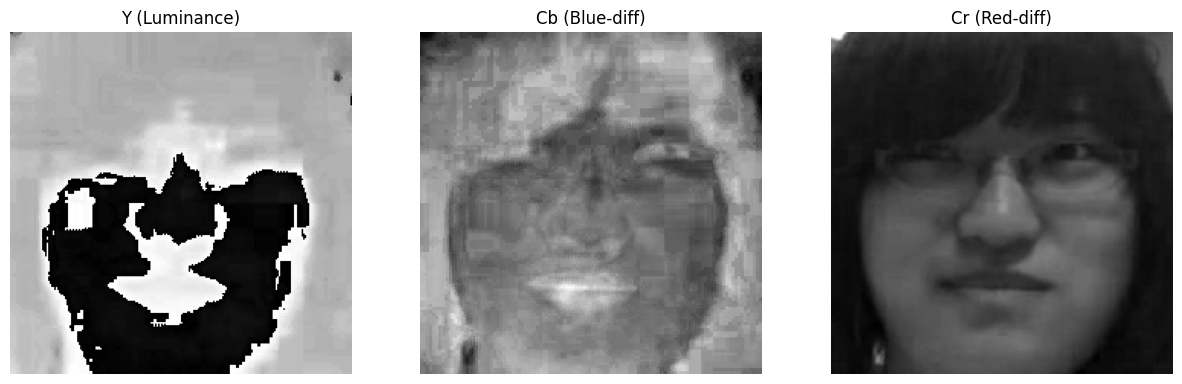

In [46]:
# Get your input data
sample_input = tf.random.uniform((1, 224, 224, 3))

# Access the layer by name and call it like a function
layer = model.get_layer("rgb_to_hsv")
output_tensor = layer(single_img) 

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
channel_names = ['Y (Luminance)', 'Cb (Blue-diff)', 'Cr (Red-diff)']
# 1. Get the output (Pass your single image)
output_tensor = layer(single_img) 

# 2. Remove the batch dimension (1, 224, 224, 3) -> (224, 224, 3)
# and convert to numpy
img_to_plot = output_tensor[0].numpy()

for i in range(3):
    axes[i].imshow(img_to_plot[:, :, i], cmap='gray')
    axes[i].set_title(channel_names[i])
    axes[i].axis('off')

plt.show()